In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import os, json
from torch.utils.data import Dataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

X_train = np.load('../data/processed/X_train.npy')
X_val   = np.load('../data/processed/X_val.npy')
X_test  = np.load('../data/processed/X_test.npy')
y_train = np.load('../data/processed/y_train.npy')
y_val   = np.load('../data/processed/y_val.npy')
y_test  = np.load('../data/processed/y_test.npy')
snr_train = np.load('../data/processed/snr_train.npy')
snr_val   = np.load('../data/processed/snr_val.npy')
snr_test  = np.load('../data/processed/snr_test.npy')

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}, snr_train: {snr_train.shape}")

#SNR normalization helpers(needed for the FiLM model's auxiliary loss)
SNR_MIN = -20.0
SNR_MAX = 18.0
SNR_MEAN = (SNR_MAX + SNR_MIN) / 2.0
SNR_SCALE = (SNR_MAX - SNR_MIN) / 2.0

def normalize_snr(snr):
    return (snr - SNR_MEAN) / SNR_SCALE

def denormalize_snr(snr_norm):
    return snr_norm * SNR_SCALE + SNR_MEAN

print(f"Check: -20 dB -> {normalize_snr(torch.tensor(-20.0)):.3f} | 18 dB -> {normalize_snr(torch.tensor(18.0)):.3f}")

Using device: cuda
X_train: (154000, 2, 128), y_train: (154000,), snr_train: (154000,)
Check: -20 dB -> -1.000 | 18 dB -> 1.000


In [3]:
class RadioMLDatasetAug(Dataset):
    def __init__(self, X, y, snr, normalize=True, augment=False):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).long()
        self.snr = torch.from_numpy(snr).float()
        self.normalize = normalize
        self.augment = augment

        if self.normalize:
            #per-sample power normalization: mean power across I and Q -> 1
            power = (self.X ** 2).sum(dim=1).mean(dim=1, keepdim=True) #(N,1)
            power = power.clamp(min=1e-8).sqrt().unsqueeze(-1) #(N,1,1)
            self.X = self.X / power

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx]

        if self.augment:
            theta = torch.rand(1) * 2 * np.pi
            cos_t, sin_t = torch.cos(theta), torch.sin(theta)
            I, Q = x[0], x[1]
            x = torch.stack([I * cos_t - Q * sin_t, I * sin_t + Q * cos_t])
        return x, self.y[idx], self.snr[idx]


train_dataset = RadioMLDatasetAug(X_train, y_train, snr_train, normalize=True, augment=True)
val_dataset   = RadioMLDatasetAug(X_val,   y_val,   snr_val,   normalize=True, augment=False)
test_dataset  = RadioMLDatasetAug(X_test,  y_test,  snr_test,  normalize=True, augment=False)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

xb, yb, sb = next(iter(train_loader))
print(f"Batch shapes: {xb.shape}, {yb.shape}, {sb.shape}")
print(f"Mean power per sample (should be ~1): {(xb**2).sum(dim=1).mean():.4f}")

Batch shapes: torch.Size([64, 2, 128]), torch.Size([64]), torch.Size([64])
Mean power per sample (should be ~1): 1.0000


In [3]:
class CNN_BiLSTM_Attention(nn.Module):
    def __init__(self, num_classes=11):
        super(CNN_BiLSTM_Attention, self).__init__()
        self.conv1 = nn.Conv1d(2, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(64)
        self.conv2 = nn.Conv1d(64, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(64)
        self.pool = nn.MaxPool1d(kernel_size=2)
        self.relu = nn.ReLU()

        self.lstm = nn.LSTM(input_size=64, hidden_size=64, num_layers=1,
                            batch_first=True, bidirectional=True)
        self.attn_fc = nn.Linear(128, 1)

        self.dropout = nn.Dropout(0.5)
        self.fc1 = nn.Linear(128, 64)
        self.fc2 = nn.Linear(64, num_classes)

    def attention(self, lstm_out):
        attn_scores = self.attn_fc(lstm_out)
        attn_weights = torch.softmax(attn_scores, dim=1)
        context = torch.sum(attn_weights * lstm_out, dim=1)
        return context, attn_weights

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.pool(out)
        out = self.relu(self.bn2(self.conv2(out)))
        out = self.pool(out)
        out = out.permute(0, 2, 1)
        lstm_out, _ = self.lstm(out)
        context, _ = self.attention(lstm_out)
        out = self.dropout(self.relu(self.fc1(context)))
        return self.fc2(out)

torch.manual_seed(42)
model = CNN_BiLSTM_Attention(num_classes=11).to(device)
print("BiLSTM+Attention model built (seed 42)")

BiLSTM+Attention model built (seed 42)


In [4]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

num_epochs = 35
best_val_acc = 0.0
history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for X_batch, y_batch, _ in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * X_batch.size(0)

    train_loss = running_loss / len(train_dataset)

    model.eval()
    val_running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch, _ in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            val_running_loss += criterion(outputs, y_batch).item() * X_batch.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)

    val_loss = val_running_loss / len(val_dataset)
    val_acc = correct / total

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    scheduler.step(val_loss)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), '../results/bilstm_improved_seed42.pt')
        marker = " <- saved"
    else:
        marker = ""

    lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1}/{num_epochs} | Train {train_loss:.4f} | Val {val_loss:.4f} | Acc {val_acc:.4f} | LR {lr:.6f}{marker}")

print(f"\nBest val accuracy: {best_val_acc:.4f}")

Epoch 1/35 | Train 1.4485 | Val 1.2635 | Acc 0.4961 | LR 0.001000 <- saved
Epoch 2/35 | Train 1.2771 | Val 1.2168 | Acc 0.5116 | LR 0.001000 <- saved
Epoch 3/35 | Train 1.2551 | Val 1.2256 | Acc 0.5102 | LR 0.001000
Epoch 4/35 | Train 1.2402 | Val 1.2031 | Acc 0.5260 | LR 0.001000 <- saved
Epoch 5/35 | Train 1.2278 | Val 1.1932 | Acc 0.5281 | LR 0.001000 <- saved
Epoch 6/35 | Train 1.2206 | Val 1.1882 | Acc 0.5288 | LR 0.001000 <- saved
Epoch 7/35 | Train 1.2147 | Val 1.1892 | Acc 0.5257 | LR 0.001000
Epoch 8/35 | Train 1.2078 | Val 1.1731 | Acc 0.5446 | LR 0.001000 <- saved
Epoch 9/35 | Train 1.1955 | Val 1.1631 | Acc 0.5475 | LR 0.001000 <- saved
Epoch 10/35 | Train 1.1767 | Val 1.1388 | Acc 0.5631 | LR 0.001000 <- saved
Epoch 11/35 | Train 1.1638 | Val 1.1602 | Acc 0.5579 | LR 0.001000
Epoch 12/35 | Train 1.1562 | Val 1.1303 | Acc 0.5699 | LR 0.001000 <- saved
Epoch 13/35 | Train 1.1497 | Val 1.1215 | Acc 0.5750 | LR 0.001000 <- saved
Epoch 14/35 | Train 1.1439 | Val 1.1281 | Acc 0.

In [5]:
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

num_epochs = 25
best_val_acc = 0.6146

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for X_batch, y_batch, _ in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * X_batch.size(0)

    train_loss = running_loss / len(train_dataset)

    model.eval()
    val_running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch, _ in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            val_running_loss += criterion(outputs, y_batch).item() * X_batch.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)

    val_loss = val_running_loss / len(val_dataset)
    val_acc = correct / total

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    scheduler.step(val_loss)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), '../results/bilstm_improved_seed42.pt')
        marker = " <- saved"
    else:
        marker = ""

    lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {len(history['train_loss'])}/60 | Train {train_loss:.4f} | Val {val_loss:.4f} | Acc {val_acc:.4f} | LR {lr:.6f}{marker}")

print(f"\nBest val accuracy: {best_val_acc:.4f}")

Epoch 36/60 | Train 1.0796 | Val 1.0559 | Acc 0.6158 | LR 0.001000 <- saved
Epoch 37/60 | Train 1.0793 | Val 1.0526 | Acc 0.6192 | LR 0.001000 <- saved
Epoch 38/60 | Train 1.0767 | Val 1.0522 | Acc 0.6184 | LR 0.001000
Epoch 39/60 | Train 1.0742 | Val 1.0518 | Acc 0.6175 | LR 0.001000
Epoch 40/60 | Train 1.0732 | Val 1.0483 | Acc 0.6195 | LR 0.001000 <- saved
Epoch 41/60 | Train 1.0717 | Val 1.0525 | Acc 0.6198 | LR 0.001000 <- saved
Epoch 42/60 | Train 1.0706 | Val 1.0464 | Acc 0.6192 | LR 0.001000
Epoch 43/60 | Train 1.0703 | Val 1.0497 | Acc 0.6178 | LR 0.001000
Epoch 44/60 | Train 1.0671 | Val 1.0518 | Acc 0.6200 | LR 0.001000 <- saved
Epoch 45/60 | Train 1.0664 | Val 1.0398 | Acc 0.6225 | LR 0.001000 <- saved
Epoch 46/60 | Train 1.0656 | Val 1.0542 | Acc 0.6205 | LR 0.001000
Epoch 47/60 | Train 1.0641 | Val 1.0485 | Acc 0.6182 | LR 0.001000
Epoch 48/60 | Train 1.0651 | Val 1.0477 | Acc 0.6190 | LR 0.001000
Epoch 49/60 | Train 1.0629 | Val 1.0445 | Acc 0.6219 | LR 0.000500
Epoch 50

In [6]:
class SNRAwareFiLMModel(nn.Module):
    def __init__(self, num_classes=11):
        super(SNRAwareFiLMModel, self).__init__()
        self.conv1 = nn.Conv1d(2, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(64)
        self.conv2 = nn.Conv1d(64, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(64)
        self.pool = nn.MaxPool1d(kernel_size=2)
        self.relu = nn.ReLU()

        self.lstm = nn.LSTM(input_size=64, hidden_size=64, num_layers=1,batch_first=True, bidirectional=True)

        self.snr_conv1 = nn.Conv1d(2, 32, kernel_size=3, padding=1)
        self.snr_gn1 = nn.GroupNorm(8, 32)
        self.snr_conv2 = nn.Conv1d(32, 32, kernel_size=3, padding=1)
        self.snr_gn2 = nn.GroupNorm(8, 32)
        self.snr_pool = nn.AdaptiveAvgPool1d(1)
        self.snr_fc = nn.Linear(32, 1)

        self.film = nn.Sequential(
            nn.Linear(1, 64),
            nn.ReLU(),
            nn.Linear(64, 128 * 2)
        )

        self.attn_fc = nn.Linear(128, 1)
        self.dropout = nn.Dropout(0.5)
        self.fc1 = nn.Linear(128, 64)
        self.fc2 = nn.Linear(64, num_classes)

    def estimate_snr(self, x):
        s = self.relu(self.snr_gn1(self.snr_conv1(x)))
        s = self.relu(self.snr_gn2(self.snr_conv2(s)))
        s = self.snr_pool(s).squeeze(-1)
        return torch.tanh(self.snr_fc(s))

    def apply_film(self, lstm_out, snr_est):
        params = self.film(snr_est)
        gamma, beta = params.chunk(2, dim=-1)
        return (1 + gamma.unsqueeze(1)) * lstm_out + beta.unsqueeze(1)

    def attention(self, feats):
        attn_weights = torch.softmax(self.attn_fc(feats), dim=1)
        return torch.sum(attn_weights * feats, dim=1), attn_weights

    def forward(self, x):
        snr_est = self.estimate_snr(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.pool(out)
        out = self.relu(self.bn2(self.conv2(out)))
        out = self.pool(out)
        out = out.permute(0, 2, 1)
        lstm_out, _ = self.lstm(out)
        modulated = self.apply_film(lstm_out, snr_est)
        context, _ = self.attention(modulated)
        out = self.dropout(self.relu(self.fc1(context)))
        return self.fc2(out), snr_est

torch.manual_seed(42)
film_model = SNRAwareFiLMModel(num_classes=11).to(device)
print("FiLM model built (seed 42)")

FiLM model built (seed 42)


In [7]:
criterion_class = nn.CrossEntropyLoss()
criterion_snr = nn.MSELoss()
lambda_snr = 0.1

optimizer = optim.Adam(film_model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

num_epochs = 60
best_val_acc = 0.0
film_history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'snr_mae': []}

for epoch in range(num_epochs):
    film_model.train()
    running_loss = 0.0
    for X_batch, y_batch, snr_batch in train_loader:
        X_batch, y_batch, snr_batch = X_batch.to(device), y_batch.to(device), snr_batch.to(device)
        snr_target = normalize_snr(snr_batch)

        optimizer.zero_grad()
        logits, snr_pred = film_model(X_batch)
        loss = criterion_class(logits, y_batch) + lambda_snr * criterion_snr(snr_pred.squeeze(), snr_target)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * X_batch.size(0)

    train_loss = running_loss / len(train_dataset)

    film_model.eval()
    val_running_loss, correct, total = 0.0, 0, 0
    snr_errs = []
    with torch.no_grad():
        for X_batch, y_batch, snr_batch in val_loader:
            X_batch, y_batch, snr_batch = X_batch.to(device), y_batch.to(device), snr_batch.to(device)
            snr_target = normalize_snr(snr_batch)

            logits, snr_pred = film_model(X_batch)
            val_running_loss += (criterion_class(logits, y_batch) + lambda_snr * criterion_snr(snr_pred.squeeze(), snr_target)).item() * X_batch.size(0)

            _, predicted = torch.max(logits, 1)
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)
            snr_errs.extend((denormalize_snr(snr_pred.squeeze()) - snr_batch).abs().cpu().numpy())

    val_loss = val_running_loss / len(val_dataset)
    val_acc = correct / total
    snr_mae = np.mean(snr_errs)

    film_history['train_loss'].append(train_loss)
    film_history['val_loss'].append(val_loss)
    film_history['val_acc'].append(val_acc)
    film_history['snr_mae'].append(float(snr_mae))

    scheduler.step(val_loss)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(film_model.state_dict(), '../results/film_improved_seed42.pt')
        marker = " <- saved"
    else:
        marker = ""

    lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1}/60 | Train {train_loss:.4f} | Val {val_loss:.4f} | Acc {val_acc:.4f} | SNR MAE {snr_mae:.2f} dB | LR {lr:.6f}{marker}")

print(f"\nBest val accuracy: {best_val_acc:.4f}")

Epoch 1/60 | Train 1.4286 | Val 1.2509 | Acc 0.5013 | SNR MAE 4.82 dB | LR 0.001000 <- saved
Epoch 2/60 | Train 1.2859 | Val 1.2346 | Acc 0.5157 | SNR MAE 4.52 dB | LR 0.001000 <- saved
Epoch 3/60 | Train 1.2637 | Val 1.2201 | Acc 0.5187 | SNR MAE 4.40 dB | LR 0.001000 <- saved
Epoch 4/60 | Train 1.2442 | Val 1.2114 | Acc 0.5256 | SNR MAE 4.20 dB | LR 0.001000 <- saved
Epoch 5/60 | Train 1.2312 | Val 1.1896 | Acc 0.5465 | SNR MAE 4.15 dB | LR 0.001000 <- saved
Epoch 6/60 | Train 1.2065 | Val 1.1740 | Acc 0.5521 | SNR MAE 4.18 dB | LR 0.001000 <- saved
Epoch 7/60 | Train 1.1902 | Val 1.1584 | Acc 0.5593 | SNR MAE 4.17 dB | LR 0.001000 <- saved
Epoch 8/60 | Train 1.1812 | Val 1.1399 | Acc 0.5666 | SNR MAE 4.25 dB | LR 0.001000 <- saved
Epoch 9/60 | Train 1.1726 | Val 1.1492 | Acc 0.5622 | SNR MAE 4.04 dB | LR 0.001000
Epoch 10/60 | Train 1.1651 | Val 1.1302 | Acc 0.5709 | SNR MAE 4.06 dB | LR 0.001000 <- saved
Epoch 11/60 | Train 1.1601 | Val 1.1365 | Acc 0.5706 | SNR MAE 4.27 dB | LR 0.

# Changing to 4 IPs

In [8]:
class RadioMLDataset4Ch(Dataset):
    def __init__(self, X, y, snr, normalize=True, augment=False, use_polar=True):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).long()
        self.snr = torch.from_numpy(snr).float()
        self.augment = augment
        self.use_polar = use_polar

        if normalize:
            power = (self.X ** 2).sum(dim=1).mean(dim=1, keepdim=True)
            power = power.clamp(min=1e-8).sqrt().unsqueeze(-1)
            self.X = self.X / power

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx] #(2, 128)

        if self.augment:
            theta = torch.rand(1) * 2 * np.pi
            cos_t, sin_t = torch.cos(theta), torch.sin(theta)
            I, Q = x[0], x[1]
            x = torch.stack([I * cos_t - Q * sin_t,I * sin_t + Q * cos_t])

        if self.use_polar:
            I, Q = x[0], x[1]
            amplitude = torch.sqrt(I**2 + Q**2 + 1e-8)
            phase = torch.atan2(Q, I) / np.pi #scale to [-1, 1]
            x = torch.stack([I, Q, amplitude, phase]) #(4, 128)
        return x, self.y[idx], self.snr[idx]


train_dataset = RadioMLDataset4Ch(X_train, y_train, snr_train, normalize=True, augment=True)
val_dataset   = RadioMLDataset4Ch(X_val,   y_val,   snr_val,   normalize=True, augment=False)
test_dataset  = RadioMLDataset4Ch(X_test,  y_test,  snr_test,  normalize=True, augment=False)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

xb, yb, sb = next(iter(train_loader))
print(f"Batch shape: {xb.shape}")
print(f"I    range: [{xb[:,0].min():.2f}, {xb[:,0].max():.2f}]")
print(f"Q    range: [{xb[:,1].min():.2f}, {xb[:,1].max():.2f}]")
print(f"Amp  range: [{xb[:,2].min():.2f}, {xb[:,2].max():.2f}]")
print(f"Phase range: [{xb[:,3].min():.2f}, {xb[:,3].max():.2f}]")

Batch shape: torch.Size([64, 4, 128])
I    range: [-2.99, 2.60]
Q    range: [-2.68, 2.20]
Amp  range: [0.01, 3.05]
Phase range: [-1.00, 1.00]


In [9]:
class CNN_BiLSTM_Attention_4Ch(nn.Module):
    def __init__(self, num_classes=11, in_channels=4):
        super(CNN_BiLSTM_Attention_4Ch, self).__init__()
        self.conv1 = nn.Conv1d(in_channels, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(64)
        self.conv2 = nn.Conv1d(64, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(64)
        self.pool = nn.MaxPool1d(kernel_size=2)
        self.relu = nn.ReLU()

        self.lstm = nn.LSTM(input_size=64, hidden_size=64, num_layers=1,batch_first=True, bidirectional=True)
        self.attn_fc = nn.Linear(128, 1)

        self.dropout = nn.Dropout(0.5)
        self.fc1 = nn.Linear(128, 64)
        self.fc2 = nn.Linear(64, num_classes)

    def attention(self, lstm_out):
        attn_weights = torch.softmax(self.attn_fc(lstm_out), dim=1)
        return torch.sum(attn_weights * lstm_out, dim=1)

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.pool(out)
        out = self.relu(self.bn2(self.conv2(out)))
        out = self.pool(out)
        out = out.permute(0, 2, 1)
        lstm_out, _ = self.lstm(out)
        context = self.attention(lstm_out)
        out = self.dropout(self.relu(self.fc1(context)))
        return self.fc2(out)

torch.manual_seed(42)
model_4ch = CNN_BiLSTM_Attention_4Ch(num_classes=11, in_channels=4).to(device)
print("4-channel BiLSTM+Attention built (seed 42)")

xb, _, _ = next(iter(train_loader))
print(f"Forward check: {model_4ch(xb.to(device)).shape}")

4-channel BiLSTM+Attention built (seed 42)
Forward check: torch.Size([64, 11])


In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_4ch.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

num_epochs = 60
best_val_acc = 0.0
hist_4ch = {'train_loss': [], 'val_loss': [], 'val_acc': []}

for epoch in range(num_epochs):
    model_4ch.train()
    running_loss = 0.0
    for X_batch, y_batch, _ in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        loss = criterion(model_4ch(X_batch), y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * X_batch.size(0)

    train_loss = running_loss / len(train_dataset)

    model_4ch.eval()
    val_running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch, _ in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model_4ch(X_batch)
            val_running_loss += criterion(outputs, y_batch).item() * X_batch.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)

    val_loss = val_running_loss / len(val_dataset)
    val_acc = correct / total

    hist_4ch['train_loss'].append(train_loss)
    hist_4ch['val_loss'].append(val_loss)
    hist_4ch['val_acc'].append(val_acc)

    scheduler.step(val_loss)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model_4ch.state_dict(), '../results/bilstm_4ch_seed42.pt')
        marker = " <- saved"
    else:
        marker = ""

    lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1}/60 | Train {train_loss:.4f} | Val {val_loss:.4f} | Acc {val_acc:.4f} | LR {lr:.6f}{marker}")

print(f"\nBest val accuracy: {best_val_acc:.4f}")

Epoch 1/60 | Train 1.4556 | Val 1.2522 | Acc 0.4962 | LR 0.001000 <- saved
Epoch 2/60 | Train 1.2786 | Val 1.2415 | Acc 0.5032 | LR 0.001000 <- saved
Epoch 3/60 | Train 1.2568 | Val 1.2336 | Acc 0.5154 | LR 0.001000 <- saved
Epoch 4/60 | Train 1.2383 | Val 1.1920 | Acc 0.5355 | LR 0.001000 <- saved
Epoch 5/60 | Train 1.2077 | Val 1.1540 | Acc 0.5476 | LR 0.001000 <- saved
Epoch 6/60 | Train 1.1861 | Val 1.1492 | Acc 0.5575 | LR 0.001000 <- saved
Epoch 7/60 | Train 1.1734 | Val 1.1405 | Acc 0.5648 | LR 0.001000 <- saved
Epoch 8/60 | Train 1.1662 | Val 1.1440 | Acc 0.5626 | LR 0.001000
Epoch 9/60 | Train 1.1571 | Val 1.1278 | Acc 0.5687 | LR 0.001000 <- saved
Epoch 10/60 | Train 1.1518 | Val 1.1334 | Acc 0.5691 | LR 0.001000 <- saved
Epoch 11/60 | Train 1.1479 | Val 1.1240 | Acc 0.5762 | LR 0.001000 <- saved
Epoch 12/60 | Train 1.1428 | Val 1.1188 | Acc 0.5751 | LR 0.001000
Epoch 13/60 | Train 1.1377 | Val 1.1050 | Acc 0.5889 | LR 0.001000 <- saved
Epoch 14/60 | Train 1.1301 | Val 1.0999

In [11]:
train_dataset_noaug = RadioMLDataset4Ch(X_train, y_train, snr_train,normalize=True, augment=False, use_polar=True)
train_loader_noaug = DataLoader(train_dataset_noaug, batch_size=64, shuffle=True)

xb, _, _ = next(iter(train_loader_noaug))
print(f"Batch shape: {xb.shape} (augment off)")

Batch shape: torch.Size([64, 4, 128]) (augment off)


In [12]:
torch.manual_seed(42)
model_noaug = CNN_BiLSTM_Attention_4Ch(num_classes=11, in_channels=4).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_noaug.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

num_epochs = 60
best_val_acc = 0.0
hist_noaug = {'train_loss': [], 'val_loss': [], 'val_acc': []}

for epoch in range(num_epochs):
    model_noaug.train()
    running_loss = 0.0
    for X_batch, y_batch, _ in train_loader_noaug:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        loss = criterion(model_noaug(X_batch), y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * X_batch.size(0)

    train_loss = running_loss / len(train_dataset_noaug)

    model_noaug.eval()
    val_running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch, _ in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model_noaug(X_batch)
            val_running_loss += criterion(outputs, y_batch).item() * X_batch.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)

    val_loss = val_running_loss / len(val_dataset)
    val_acc = correct / total

    hist_noaug['train_loss'].append(train_loss)
    hist_noaug['val_loss'].append(val_loss)
    hist_noaug['val_acc'].append(val_acc)

    scheduler.step(val_loss)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model_noaug.state_dict(), '../results/bilstm_4ch_noaug_seed42.pt')
        marker = " <- saved"
    else:
        marker = ""

    lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1}/60 | Train {train_loss:.4f} | Val {val_loss:.4f} | Acc {val_acc:.4f} | LR {lr:.6f}{marker}")

print(f"\nBest val accuracy: {best_val_acc:.4f}")

Epoch 1/60 | Train 1.4370 | Val 1.2447 | Acc 0.5172 | LR 0.001000 <- saved
Epoch 2/60 | Train 1.2487 | Val 1.1866 | Acc 0.5398 | LR 0.001000 <- saved
Epoch 3/60 | Train 1.2086 | Val 1.1718 | Acc 0.5474 | LR 0.001000 <- saved
Epoch 4/60 | Train 1.1801 | Val 1.1390 | Acc 0.5612 | LR 0.001000 <- saved
Epoch 5/60 | Train 1.1568 | Val 1.1281 | Acc 0.5728 | LR 0.001000 <- saved
Epoch 6/60 | Train 1.1427 | Val 1.1252 | Acc 0.5670 | LR 0.001000
Epoch 7/60 | Train 1.1290 | Val 1.1162 | Acc 0.5759 | LR 0.001000 <- saved
Epoch 8/60 | Train 1.1189 | Val 1.1028 | Acc 0.5894 | LR 0.001000 <- saved
Epoch 9/60 | Train 1.1069 | Val 1.0914 | Acc 0.5946 | LR 0.001000 <- saved
Epoch 10/60 | Train 1.0967 | Val 1.0909 | Acc 0.5976 | LR 0.001000 <- saved
Epoch 11/60 | Train 1.0889 | Val 1.0911 | Acc 0.5974 | LR 0.001000
Epoch 12/60 | Train 1.0820 | Val 1.0904 | Acc 0.5953 | LR 0.001000
Epoch 13/60 | Train 1.0751 | Val 1.0880 | Acc 0.6025 | LR 0.001000 <- saved
Epoch 14/60 | Train 1.0691 | Val 1.0865 | Acc 0.

KeyboardInterrupt: 

In [4]:
class MultiScaleCNN_BiLSTM_Attention(nn.Module):
    def __init__(self, num_classes=11, in_channels=4):
        super(MultiScaleCNN_BiLSTM_Attention, self).__init__()

        #Multi-scale first stage: 3 parallel branches
        self.branch3 = nn.Sequential(
            nn.Conv1d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32), nn.ReLU())
        self.branch5 = nn.Sequential(
            nn.Conv1d(in_channels, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32), nn.ReLU())
        self.branch7 = nn.Sequential(
            nn.Conv1d(in_channels, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32), nn.ReLU())
        #concat -> 96 channels
        self.pool = nn.MaxPool1d(2)

        #Second stage on fused features
        self.conv2 = nn.Conv1d(96, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(64)
        self.relu = nn.ReLU()

        self.lstm = nn.LSTM(input_size=64, hidden_size=64, num_layers=1,batch_first=True, bidirectional=True)
        self.attn_fc = nn.Linear(128, 1)

        self.dropout = nn.Dropout(0.5)
        self.fc1 = nn.Linear(128, 64)
        self.fc2 = nn.Linear(64, num_classes)

    def attention(self, lstm_out):
        attn_weights = torch.softmax(self.attn_fc(lstm_out), dim=1)
        return torch.sum(attn_weights * lstm_out, dim=1)

    def forward(self, x):
        out = torch.cat([self.branch3(x), self.branch5(x), self.branch7(x)], dim=1) # (B, 96, 128)
        out = self.pool(out) # (B, 96, 64)
        out = self.relu(self.bn2(self.conv2(out))) # (B, 64, 64)
        out = self.pool(out) # (B, 64, 32)
        out = out.permute(0, 2, 1)
        lstm_out, _ = self.lstm(out)
        context = self.attention(lstm_out)
        out = self.dropout(self.relu(self.fc1(context)))
        return self.fc2(out)

torch.manual_seed(42)
model_ms = MultiScaleCNN_BiLSTM_Attention(num_classes=11, in_channels=2).to(device)

n_params = sum(p.numel() for p in model_ms.parameters())
print(f"Multi-scale model built | {n_params:,} parameters")

xb, _, _ = next(iter(train_loader))
print(f"Forward check: {model_ms(xb.to(device)).shape}")

Multi-scale model built | 95,532 parameters
Forward check: torch.Size([64, 11])


In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_ms.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

num_epochs = 60
best_val_acc = 0.0
hist_ms = {'train_loss': [], 'val_loss': [], 'val_acc': []}

for epoch in range(num_epochs):
    model_ms.train()
    running_loss = 0.0
    for X_batch, y_batch, _ in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        loss = criterion(model_ms(X_batch), y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * X_batch.size(0)

    train_loss = running_loss / len(train_dataset)

    model_ms.eval()
    val_running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch, _ in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model_ms(X_batch)
            val_running_loss += criterion(outputs, y_batch).item() * X_batch.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)

    val_loss = val_running_loss / len(val_dataset)
    val_acc = correct / total

    hist_ms['train_loss'].append(train_loss)
    hist_ms['val_loss'].append(val_loss)
    hist_ms['val_acc'].append(val_acc)

    scheduler.step(val_loss)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model_ms.state_dict(), '../results/multiscale_seed42.pt')
        marker = " <- saved"
    else:
        marker = ""

    lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1}/60 | Train {train_loss:.4f} | Val {val_loss:.4f} | Acc {val_acc:.4f} | LR {lr:.6f}{marker}")

print(f"\nBest val accuracy: {best_val_acc:.4f}")

Epoch 1/60 | Train 1.4115 | Val 1.2323 | Acc 0.5055 | LR 0.001000 <- saved
Epoch 2/60 | Train 1.2677 | Val 1.2144 | Acc 0.5094 | LR 0.001000 <- saved
Epoch 3/60 | Train 1.2339 | Val 1.1817 | Acc 0.5460 | LR 0.001000 <- saved
Epoch 4/60 | Train 1.2008 | Val 1.1614 | Acc 0.5525 | LR 0.001000 <- saved
Epoch 5/60 | Train 1.1832 | Val 1.1439 | Acc 0.5575 | LR 0.001000 <- saved
Epoch 6/60 | Train 1.1718 | Val 1.1396 | Acc 0.5659 | LR 0.001000 <- saved
Epoch 7/60 | Train 1.1639 | Val 1.1360 | Acc 0.5608 | LR 0.001000
Epoch 8/60 | Train 1.1587 | Val 1.1235 | Acc 0.5708 | LR 0.001000 <- saved
Epoch 9/60 | Train 1.1510 | Val 1.1208 | Acc 0.5677 | LR 0.001000
Epoch 10/60 | Train 1.1464 | Val 1.1181 | Acc 0.5666 | LR 0.001000
Epoch 11/60 | Train 1.1419 | Val 1.1166 | Acc 0.5737 | LR 0.001000 <- saved
Epoch 12/60 | Train 1.1384 | Val 1.1165 | Acc 0.5735 | LR 0.001000
Epoch 13/60 | Train 1.1344 | Val 1.1245 | Acc 0.5755 | LR 0.001000 <- saved
Epoch 14/60 | Train 1.1287 | Val 1.1078 | Acc 0.5875 | LR

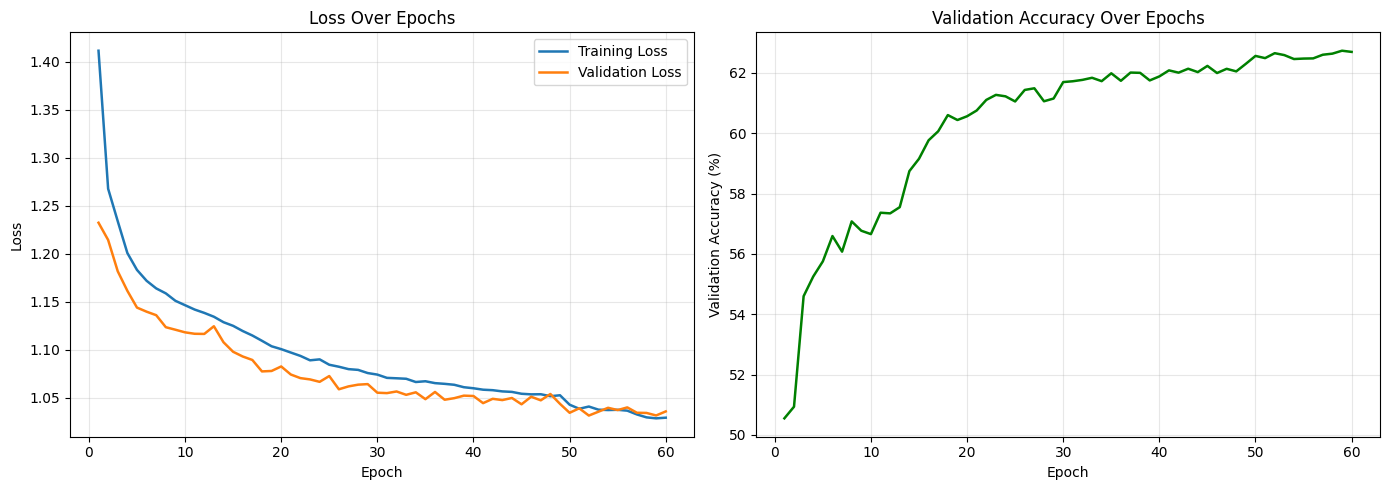

In [6]:
epochs = range(1, len(hist_ms['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, hist_ms['train_loss'], label='Training Loss', linewidth=1.8)
axes[0].plot(epochs, hist_ms['val_loss'],   label='Validation Loss', linewidth=1.8)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Loss Over Epochs')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, [a*100 for a in hist_ms['val_acc']], color='green', linewidth=1.8)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Validation Accuracy (%)')
axes[1].set_title('Validation Accuracy Over Epochs')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/figures/training_curves.png', dpi=300, bbox_inches='tight')
plt.show()